# **Digital Assignment 1**
## **Subject: Deep Learning Lab (PMDS603P)**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.datasets import mnist

# **Question 1**

In [6]:
# OR Gate
def mcp_or_gate(x1, x2):
    theta = 1 
    result = 1 if x1 + x2 >= theta else 0
    return result

# AND Gate
def mcp_and_gate(x1, x2):
    theta = 2 
    result = 1 if x1 + x2 >= theta else 0
    return result

In [3]:
input_x1 = [0, 0, 1, 1]
input_x2 = [0, 1, 0, 1]

for i in range(len(input_x1)):
    res = mcp_or_gate(input_x1[i], input_x2[i])
    print(res)

0
1
1
1


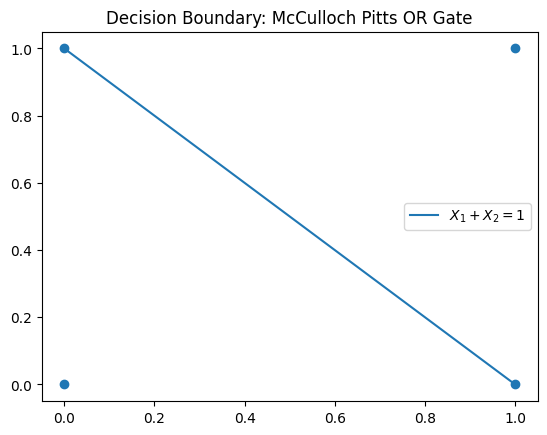

In [4]:
l1 = np.linspace(0, 1, 100)
l2 = 1 - l1
plt.scatter(input_x1, input_x2)
plt.title("Decision Boundary: McCulloch Pitts OR Gate")
plt.plot(l1, l2, label = '${X_1} + {X_2} = {1}$')
plt.legend()
plt.show()

In [7]:
for i in range(len(input_x1)):
    print(mcp_and_gate(input_x1[i], input_x2[i]))

0
0
0
1


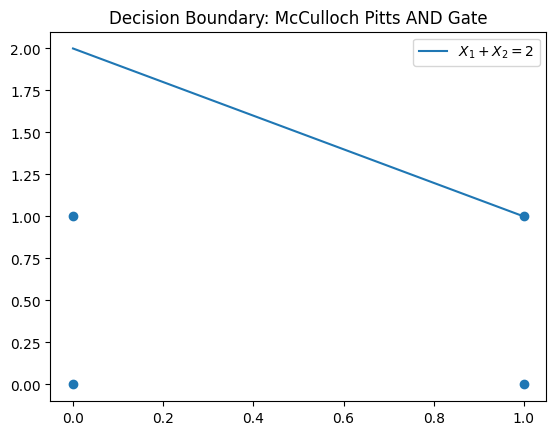

In [8]:
l1 = np.linspace(0, 1, 100)
l2 = 2 - l1
plt.scatter(input_x1, input_x2)
plt.title("Decision Boundary: McCulloch Pitts AND Gate")
plt.plot(l1, l2, label = '${X_1} + {X_2} = {2}$')
plt.legend()
plt.show()

# **Question 2**

In [9]:
X = np.array([
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])  


OR   = np.array([0, 1, 1, 1])
AND  = np.array([0, 0, 0, 1])
NAND = np.array([1, 1, 1, 0])
NOR  = np.array([1, 0, 0, 0])


def train(X, y, epochs=10):
    w = np.zeros(X.shape[1])  

    for i in range(epochs):
        err = 0
        for xi, target in zip(X, y):
            res = np.dot(w, xi)
            if target == 1 and res < 0:
                w = w + xi  
                err += 1
            elif target == 0 and res >= 0:
                w = w - xi
                err += 1
        if err == 0:
            print(f"Converged after {i+1} epochs")
            break
    return w

In [10]:
print("Training OR gate:")
w_or = train(X, OR, epochs=10)
print("Final Weights (OR):", w_or)

print("\nTraining AND gate:")
w_and = train(X, AND, epochs=10)
print("Final Weights (AND):", w_and)

print("\nTraining NAND gate:")
w_nand = train(X, NAND, epochs=10)
print("Final Weights (NAND):", w_nand)

print("\nTraining NOR gate:")
w_nor = train(X, NOR, epochs=10)
print("Final Weights (NOR):", w_nor)

Training OR gate:
Converged after 4 epochs
Final Weights (OR): [-1.  1.  1.]

Training AND gate:
Converged after 6 epochs
Final Weights (AND): [-3.  2.  1.]

Training NAND gate:
Converged after 6 epochs
Final Weights (NAND): [ 2. -2. -1.]

Training NOR gate:
Converged after 4 epochs
Final Weights (NOR): [ 0. -1. -1.]


# **Question 3**

In [12]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

In [20]:
model = Sequential()
model.add(Dense(4, input_dim=2, activation='sigmoid'))
model.add(Dense(2, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="binary_crossentropy", optimizer='adam', metrics=['accuracy'])
model.fit(X, y, epochs=2000, verbose=1)

In [28]:
pred = model.predict(X)

predicted = (pred >= 0.5).astype(int)
print(predicted)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0]
 [1]
 [1]
 [0]]


# **Question 4**

In [30]:
df = pd.read_csv("liver_patient.csv")
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,liver_disease
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [32]:
df.drop('Gender', axis=1, inplace=True)
MM = MinMaxScaler()
x = MM.fit_transform(df)

In [34]:
X = x[:, 0:9]
Y = x[:, 9]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state=1)

In [38]:
LR = LogisticRegression()
LR.fit(X_train, y_train)
print(accuracy_score(LR.predict(X_test), y_test))

0.717948717948718


### Using Keras

In [40]:
model2 = Sequential()
model2.add(Dense(1, activation='sigmoid', input_shape=(9,)))
model2.summary()


e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(loss='BinaryCrossentropy', optimizer=SGD(), metrics= ['accuracy'])
model2.fit(X_train, y_train, batch_size=50, epochs = 100, verbose = 1, validation_data= (X_test, y_test))

### Using 2 layers

In [44]:
y_train2 = keras.utils.to_categorical(y_train, 2)
y_test2 = keras.utils.to_categorical(y_test, 2)

model3 = Sequential()
model3.add(Dense(2, activation='softmax', input_shape=(9,)))
model2.add(Dense(1, activation='sigmoid'))
model3.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(loss='CategoricalCrossentropy', optimizer='SGD', metrics=['accuracy'])
model3.fit(X_train, y_train2, batch_size=50, epochs=100, verbose=1, validation_data=(X_test, y_test2))

In [46]:
y_pred = np.argmax(model3.predict(X_test), axis=1)
y_pred

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/stepWARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000025C4C35D4E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1])

In [47]:
model4 = Sequential()
model4.add(Dense(10, activation='sigmoid', input_shape=(9,)))
model4.add(Dense(1, activation = 'sigmoid'))
model4.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111 (444.00 B)

 Trainable params: 111 (444.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model4.compile(loss='BinaryCrossentropy', optimizer='SGD', metrics=['accuracy'])
model4.fit(X_train, y_train, batch_size=10, epochs=100,verbose=1, validation_data=(X_test, y_test))


In [59]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model4.evaluate(X_test, y_test, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=0.6011, acc=0.7094


# **Question 5**

In [49]:
model5 = Sequential()
model5.add(Dense(10, activation='relu', input_shape=(9,)))
model5.add(Dense(1, activation = 'sigmoid'))
model5.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111 (444.00 B)

 Trainable params: 111 (444.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model5.compile(loss='BinaryCrossentropy', optimizer='SGD', metrics=['accuracy'])
model5.fit(X_train, y_train, batch_size=50, epochs=1000,verbose=1, validation_data=(X_test, y_test))


In [58]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model5.evaluate(X_test, y_test, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=0.5339, acc=0.7265


# **Question 6**

In [62]:
batch_size = 128
num_classes = 10
epochs = 10
(X_train, y_train), (X_test, y_test) = mnist.load_data()

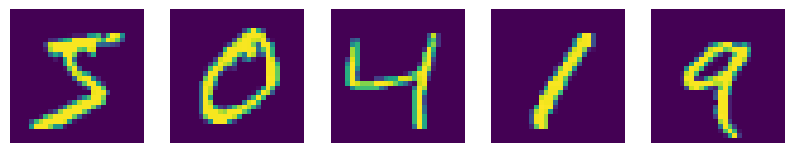

In [68]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axs[i].imshow(X_train[i])
    axs[i].axis('off')    


plt.show()

In [72]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255


y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [ ]:
model6 = Sequential()
model6.add(Dense(512, activation='relu', input_shape=(784,)))
model6.add(Dense(256, activation='relu'))
model6.add(Dense(128, activation='relu'))
model6.add(Dense(10, activation = 'softmax'))
model6.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model6.compile(loss='CategoricalCrossentropy', optimizer='SGD', metrics=['accuracy'])
hist1 = model6.fit(X_train, y_train_cat, batch_size=64, epochs=50,verbose=1, validation_data=(X_test, y_test_cat))

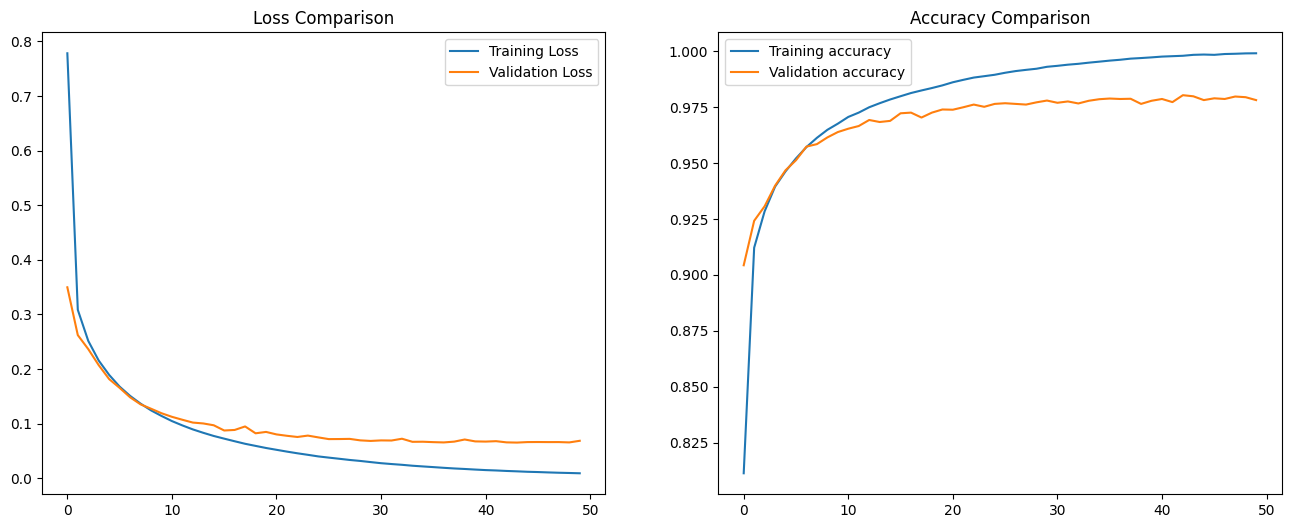

In [81]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist1.history['loss'], label='Training Loss')
axs[0].plot(hist1.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist1.history['accuracy'], label='Training accuracy')
axs[1].plot(hist1.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

In [82]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model6.evaluate(X_test, y_test_cat, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=0.0686, acc=0.9782


In [83]:
predictions = model6.predict(X_test)
for i in range(5):
    predicted_class = np.argmax(predictions[i])
    true_class = np.argmax(y_test_cat[i])
    print(f"Image {i+1}: Predicted = {predicted_class}, True = {true_class}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Image 1: Predicted = 7, True = 7
Image 2: Predicted = 2, True = 2
Image 3: Predicted = 1, True = 1
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 4, True = 4


# **Question 7**

In [84]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# inputs
X = np.array([[0, 0, 1],
              [0, 1, 1],
              [1, 0, 1],
              [1, 1, 1]])

# Output 
y = np.array([[0],
              [1],
              [1],
              [0]])


synapse0 = 2 * np.random.random((3, 4)) - 1
synapse1 = 2 * np.random.random((4, 1)) - 1

print("Initial random weights for synapse0:")
print(synapse0)
print("\nInitial random weights for synapse1:")
print(synapse1)

Initial random weights for synapse0:
[[ 0.29318751  0.82489723  0.24740355 -0.0914329 ]
 [ 0.75338747  0.47722728  0.63611561 -0.45729737]
 [ 0.78844343  0.3534294   0.35984842  0.63072422]]

Initial random weights for synapse1:
[[ 0.23642771]
 [ 0.33431148]
 [ 0.4939262 ]
 [-0.05556232]]


In [85]:
epochs = 1000
for j in range(epochs):
    layer_0 = X
    layer_1 = sigmoid(np.dot(layer_0, synapse0))
    layer_2 = sigmoid(np.dot(layer_1, synapse1))
 
    layer_2_error = y - layer_2
    if (j % 10000) == 0:
        print(f"\nError after {j} iterations: {np.mean(np.abs(layer_2_error)):.5f}")

    layer_2_delta = layer_2_error * sigmoid_derivative(layer_2)
    layer_1_error = layer_2_delta.dot(synapse1.T)
    layer_1_delta = layer_1_error * sigmoid_derivative(layer_1)
    
    synapse1 += layer_1.T.dot(layer_2_delta)
    synapse0 += layer_0.T.dot(layer_1_delta)


Error after 0 iterations: 0.49854


In [86]:
print("\nOutput after training:")
print(layer_2)

classified_output = (layer_2 > 0.5).astype(int)
print("\nClassified Output after training (0 or 1):")
print(classified_output)

print("\nFinal weights for synapse0:")
print(synapse0)
print("\nFinal weights for synapse1:")
print(synapse1)

# Test
print("\nTesting with a new situation [1, 0, 0]:")
new_input = np.array([1, 0, 0])
l1 = sigmoid(np.dot(new_input, synapse0))
l2 = sigmoid(np.dot(l1, synapse1))
print("Prediction for [1, 0, 0]:")
print(l2)


Output after training:
[[0.02580342]
 [0.9312312 ]
 [0.93026684]
 [0.0813929 ]]

Classified Output after training (0 or 1):
[[0]
 [1]
 [1]
 [0]]

Final weights for synapse0:
[[-2.45282907  5.31224898  1.20194094  5.66534711]
 [ 5.49880782  5.28182999  1.70797917 -2.77990854]
 [ 0.1232944  -0.96991792 -2.13137484  0.38976442]]

Final weights for synapse1:
[[-5.11317583]
 [ 9.12106475]
 [-2.14437016]
 [-5.36405985]]

Testing with a new situation [1, 0, 0]:
Prediction for [1, 0, 0]:
[0.84249354]
